<a href="https://colab.research.google.com/github/Gurkamal-kaur/Business-project-part-2/blob/main/Market_basket_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Step 1: Import Libraries

# Core data analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Association rule mining
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# Machine learning (optional clustering / segmentation)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Date/time handling
import datetime as dt

# Google Drive file download
!pip install gdown
import gdown

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# Step 2: Load Dataset

# dataset link:
# https://drive.google.com/file/d/1LgnjuKUWrxb837khcdHDX6ox8o62XOkS/view?usp=sharing

# Extract the file ID from the link
file_id = "1LgnjuKUWrxb837khcdHDX6ox8o62XOkS"
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file into Colab using gdown
output = "dataset.csv"   # change extension if your file is Excel
gdown.download(url, output, quiet=False)

# Load the dataset with pandas
# If your file is CSV:
data = pd.read_csv("dataset.csv")

# If your file is Excel, use:
# data = pd.read_excel("dataset.xlsx")

# Preview the first 5 rows
data.head()


Downloading...
From: https://drive.google.com/uc?id=1LgnjuKUWrxb837khcdHDX6ox8o62XOkS
To: /content/dataset.csv
100%|██████████| 224k/224k [00:00<00:00, 51.7MB/s]


,TransactionID,CustomerID,TransactionDate,ProductID,ProductName,Quantity,UnitPrice
0,TX200001,C10416,2025-06-04,MB009,Granola Bar,2,841
1,TX200002,C10782,2025-04-03,MB028,Notebook,1,743
2,TX200002,C10782,2025-04-03,MB030,Sticky Notes,1,568
3,TX200003,C10836,2025-03-23,MB001,Coffee Beans,1,775
4,TX200003,C10836,2025-03-23,MB002,Instant Coffee,2,249


In [5]:
# Step 3: Data Understanding

# Check the shape of the dataset (rows, columns)
print("Dataset shape:", data.shape)

# See column names and data types
print("\nDataset info:")
print(data.info())

# Summary statistics for numerical columns
print("\nSummary statistics:")
print(data.describe())

# Count missing values in each column
print("\nMissing values per column:")
print(data.isnull().sum())

# Preview first 5 rows
print("\nFirst 5 rows:")
print(data.head())

# Preview last 5 rows
print("\nLast 5 rows:")
print(data.tail())

# Check unique values in key columns
if 'CustomerID' in data.columns:
    print("\nUnique Customers:", data['CustomerID'].nunique())
else:
    print("\nCustomerID column not found")

if 'ProductName' in data.columns:
    print("Unique Products:", data['ProductName'].nunique())
else:
    print("ProductName column not found")

if 'TransactionID' in data.columns:
    print("Unique Transactions:", data['TransactionID'].nunique())
else:
    print("TransactionID column not found")


Dataset shape: (4311, 7)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4311 entries, 0 to 4310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    4311 non-null   object
 1   CustomerID       4311 non-null   object
 2   TransactionDate  4311 non-null   object
 3   ProductID        4311 non-null   object
 4   ProductName      4286 non-null   object
 5   Quantity         4311 non-null   int64 
 6   UnitPrice        4311 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 235.9+ KB
None

Summary statistics:
          Quantity    UnitPrice
count  4311.000000  4311.000000
mean      1.413825   490.854790
std       0.762177   227.791302
min       0.000000    84.000000
25%       1.000000   283.000000
50%       1.000000   459.000000
75%       2.000000   728.000000
max       4.000000   841.000000

Missing values per column:
TransactionID       0
CustomerID          0
Transaction

In [6]:
# Step 4: Data Cleaning

# 1. Remove rows with missing CustomerID
data = data.dropna(subset=['CustomerID'])

# 2. Remove rows with missing product names
data = data.dropna(subset=['ProductName'])

# 3. Remove rows with negative or zero quantities
data = data[data['Quantity'] > 0]

# 4. Remove rows with zero or negative unit prices
data = data[data['UnitPrice'] > 0]

# 5. Remove duplicate records
data = data.drop_duplicates()

# 6. Convert TransactionDate to datetime format (handle errors)
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], errors='coerce')

# ✅ Check the cleaned dataset
print("Cleaned dataset shape:", data.shape)
print("\nMissing values after cleaning:")
print(data.isnull().sum())

# Preview first 5 rows after cleaning
print("\nFirst 5 rows after cleaning:")
print(data.head())


Cleaned dataset shape: (4215, 7)

Missing values after cleaning:
TransactionID      0
CustomerID         0
TransactionDate    0
ProductID          0
ProductName        0
Quantity           0
UnitPrice          0
dtype: int64

First 5 rows after cleaning:
  TransactionID CustomerID TransactionDate ProductID     ProductName  \
0      TX200001     C10416      2025-06-04     MB009     Granola Bar   
1      TX200002     C10782      2025-04-03     MB028        Notebook   
2      TX200002     C10782      2025-04-03     MB030    Sticky Notes   
3      TX200003     C10836      2025-03-23     MB001    Coffee Beans   
4      TX200003     C10836      2025-03-23     MB002  Instant Coffee   

   Quantity  UnitPrice  
0         2        841  
1         1        743  
2         1        568  
3         1        775  
4         2        249  


In [7]:
# Step 5: Feature Engineering

# Make sure TransactionDate is in datetime format
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], errors='coerce')

# Create a new column for Revenue
data['Revenue'] = data['Quantity'] * data['UnitPrice']

# --- Customer-level features ---
customer_features = data.groupby('CustomerID').agg({
    'Revenue': 'sum',                          # Total revenue per customer
    'TransactionID': 'count',                  # Total number of transactions
    'Quantity': 'sum',                         # Total quantity purchased
    'UnitPrice': 'mean',                       # Average unit price
    'ProductName': pd.Series.nunique           # Number of unique products purchased
}).reset_index()

# Rename columns for clarity
customer_features.rename(columns={
    'Revenue': 'TotalRevenue',
    'TransactionID': 'TotalTransactions',
    'Quantity': 'TotalQuantity',
    'UnitPrice': 'AvgUnitPrice',
    'ProductName': 'UniqueProducts'
}, inplace=True)

print("Customer-level features:")
print(customer_features.head())

# --- Build RFM Table ---
latest_date = data['TransactionDate'].max()

rfm = data.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (latest_date - x.max()).days,  # Recency
    'TransactionID': 'count',                                   # Frequency
    'Revenue': 'sum'                                            # Monetary
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

print("\nRFM Table:")
print(rfm.head())


Customer-level features:
  CustomerID  TotalRevenue  TotalTransactions  TotalQuantity  AvgUnitPrice  \
0     C10001          1989                  4              4    497.250000   
1     C10002          1427                  3              3    475.666667   
2     C10003          1174                  3              3    391.333333   
3     C10004          2556                  5              7    316.200000   
4     C10005          2653                  2              4    536.500000   

   UniqueProducts  
0               3  
1               3  
2               3  
3               3  
4               2  

RFM Table:
  CustomerID  Recency  Frequency  Monetary
0     C10001        1          4      1989
1     C10002       65          3      1427
2     C10003       21          3      1174
3     C10004       46          5      2556
4     C10005       78          2      2653


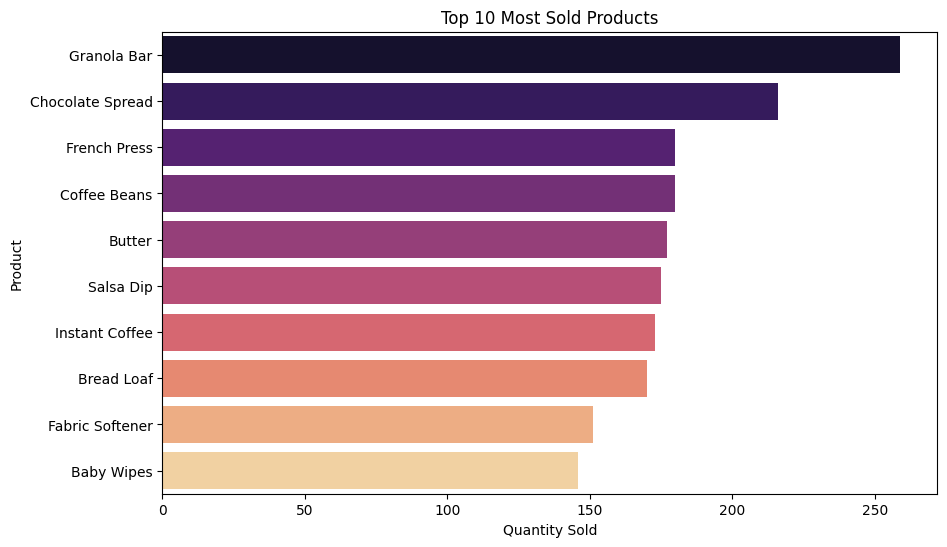

Interpretation: Everyday items dominate sales volume, showing customer preferences.


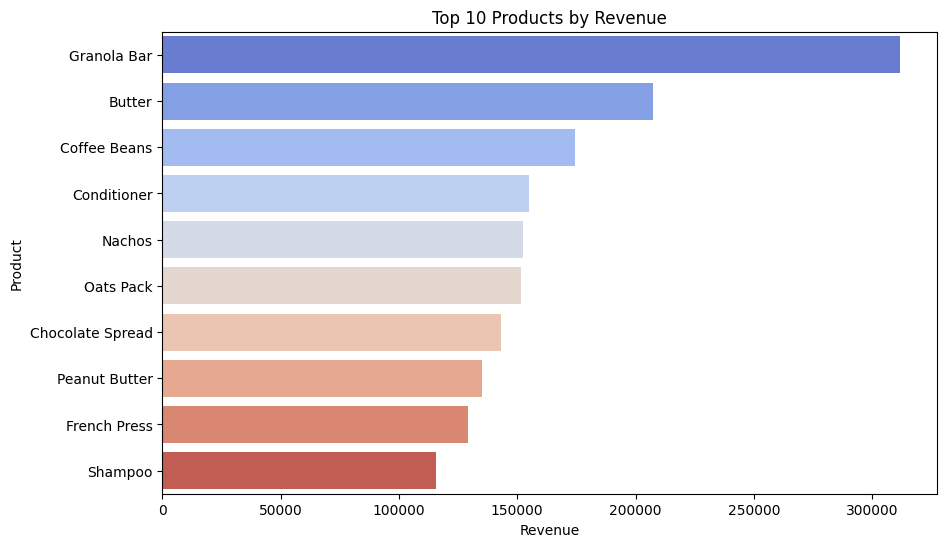

Interpretation: High-value items generate more revenue even if sold less frequently.


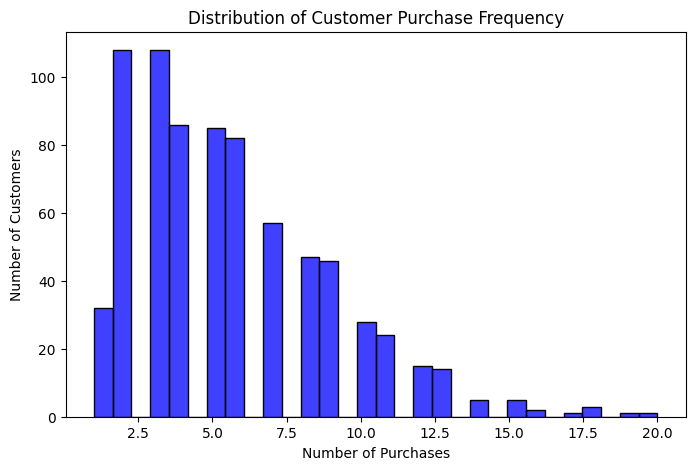

Interpretation: Most customers purchase only a few times, while a small group buys frequently.


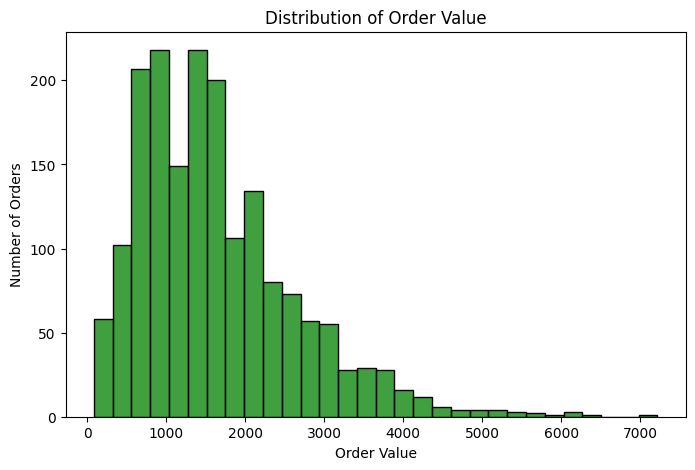

Interpretation: Majority of orders are low-value, but a few large orders contribute significantly.


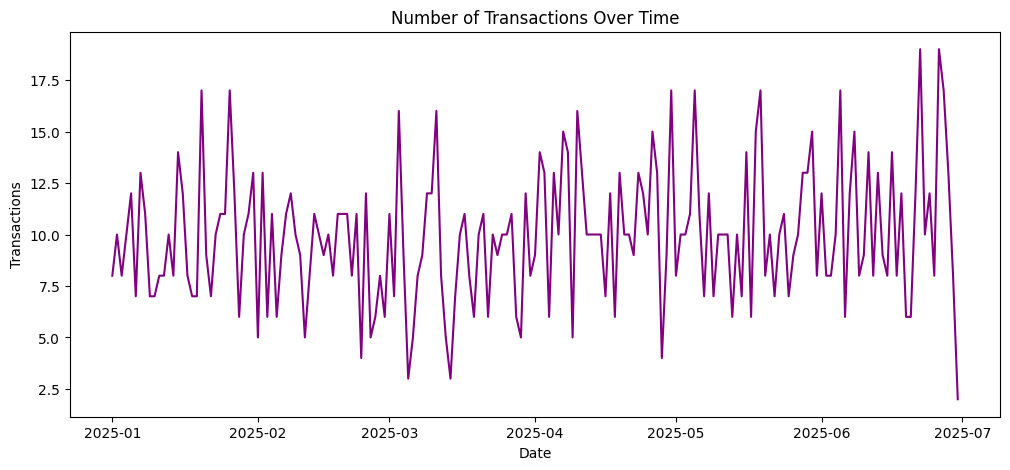

Interpretation: Peaks and troughs highlight busy and slow periods, guiding inventory and staffing decisions.


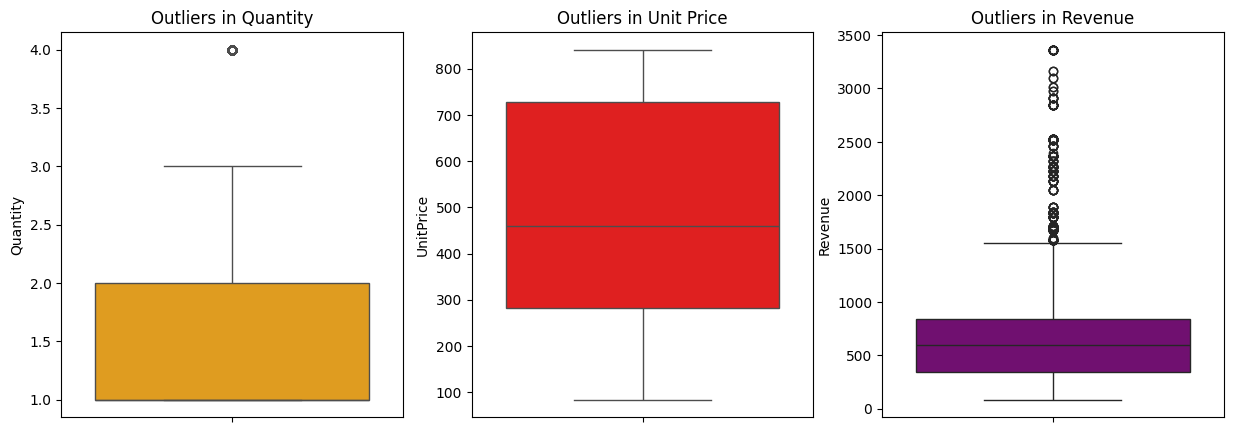

Interpretation: Extreme outliers exist in quantity and price, likely due to bulk orders or data entry errors.


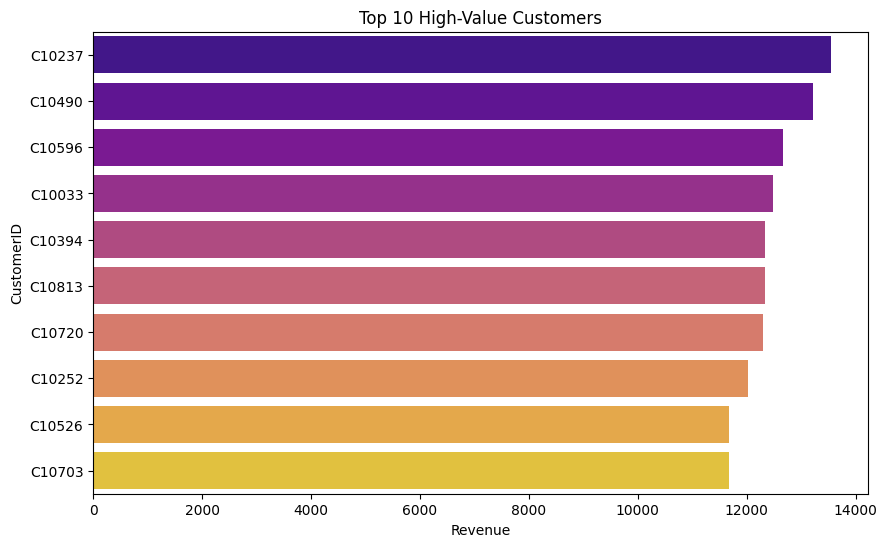

Interpretation: A small set of customers contribute disproportionately to total revenue.


In [8]:
# Step 6: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 Most Sold Products
top_products = data['ProductName'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="magma")
plt.title("Top 10 Most Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.show()
print("Interpretation: Everyday items dominate sales volume, showing customer preferences.")

# 2. Top 10 Products by Revenue
product_revenue = data.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=product_revenue.values, y=product_revenue.index, palette="coolwarm")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()
print("Interpretation: High-value items generate more revenue even if sold less frequently.")

# 3. Distribution of Customer Purchase Frequency
plt.figure(figsize=(8,5))
sns.histplot(data.groupby('CustomerID')['TransactionID'].count(), bins=30, kde=False, color="blue")
plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()
print("Interpretation: Most customers purchase only a few times, while a small group buys frequently.")

# 4. Distribution of Order Value
order_value = data.groupby('TransactionID')['Revenue'].sum()
plt.figure(figsize=(8,5))
sns.histplot(order_value, bins=30, kde=False, color="green")
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.show()
print("Interpretation: Majority of orders are low-value, but a few large orders contribute significantly.")

# 5. Transactions Over Time
data['TransactionDate'] = pd.to_datetime(data['TransactionDate'], errors='coerce')
daily_sales = data.groupby(data['TransactionDate'].dt.date)['TransactionID'].nunique()
plt.figure(figsize=(12,5))
daily_sales.plot(kind='line', color="purple")
plt.title("Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.show()
print("Interpretation: Peaks and troughs highlight busy and slow periods, guiding inventory and staffing decisions.")

# 6. Outliers in Quantity, UnitPrice, Revenue
fig, axes = plt.subplots(1,3, figsize=(15,5))
sns.boxplot(y=data['Quantity'], ax=axes[0], color="orange")
axes[0].set_title("Outliers in Quantity")
sns.boxplot(y=data['UnitPrice'], ax=axes[1], color="red")
axes[1].set_title("Outliers in Unit Price")
sns.boxplot(y=data['Revenue'], ax=axes[2], color="purple")
axes[2].set_title("Outliers in Revenue")
plt.show()
print("Interpretation: Extreme outliers exist in quantity and price, likely due to bulk orders or data entry errors.")

# 7. Top 10 High-Value Customers
top_customers = data.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette="plasma")
plt.title("Top 10 High-Value Customers")
plt.xlabel("Revenue")
plt.ylabel("CustomerID")
plt.show()
print("Interpretation: A small set of customers contribute disproportionately to total revenue.")


In [10]:
# Step 7: Transaction Basket Preparation

import pandas as pd

# --- Prepare basket data for association rule mining ---

# 1. Group transactions by TransactionID and ProductName
basket = (data.groupby(['TransactionID', 'ProductName'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('TransactionID'))

# 2. Convert quantities to binary (0/1) for presence/absence
basket_sets = basket.applymap(lambda x: 1 if x > 0 else 0)

print("Basket shape:", basket_sets.shape)

# Display basket sample with borders
print("\nBasket sample (first 5 transactions):")
display(basket_sets.head().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]}]
).set_properties(**{'border': '1px solid black'}))

# --- Customer-level basket (optional) ---
# If you want to analyze baskets at customer level instead of transaction level:
customer_basket = (data.groupby(['CustomerID', 'ProductName'])['Quantity']
                   .sum().unstack().reset_index().fillna(0)
                   .set_index('CustomerID'))

customer_basket_sets = customer_basket.applymap(lambda x: 1 if x > 0 else 0)

print("\nCustomer basket shape:", customer_basket_sets.shape)

# Display customer basket sample with borders
print("\nCustomer basket sample (first 5 customers):")
display(customer_basket_sets.head().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]}]
).set_properties(**{'border': '1px solid black'}))


Basket shape: (1799, 30)

Basket sample (first 5 transactions):


ProductName,Almond Pack,Baby Diapers,Baby Lotion,Baby Wipes,Black Tea,Body Wash,Bread Loaf,Butter,Chocolate Spread,Coffee Beans,Conditioner,Dishwash Liquid,Electrolyte Drink,Fabric Softener,French Press,Granola Bar,Green Tea,Honey Jar,Instant Coffee,Laundry Detergent,Nachos,Notebook,Oats Pack,Peanut Butter,Pen Pack,Potato Chips,Protein Bar,Salsa Dip,Shampoo,Sticky Notes
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TX200001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TX200002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
TX200003,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
TX200004,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TX200005,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0



Customer basket shape: (750, 30)

Customer basket sample (first 5 customers):


ProductName,Almond Pack,Baby Diapers,Baby Lotion,Baby Wipes,Black Tea,Body Wash,Bread Loaf,Butter,Chocolate Spread,Coffee Beans,Conditioner,Dishwash Liquid,Electrolyte Drink,Fabric Softener,French Press,Granola Bar,Green Tea,Honey Jar,Instant Coffee,Laundry Detergent,Nachos,Notebook,Oats Pack,Peanut Butter,Pen Pack,Potato Chips,Protein Bar,Salsa Dip,Shampoo,Sticky Notes
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
C10001,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
C10002,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
C10003,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
C10004,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
C10005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [11]:
# Step 8: Frequent Itemset Generation

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# --- Using Transaction-level basket prepared in Step 7 ---
# basket_sets contains binary (0/1) values for product presence

# 1. Generate frequent itemsets using Apriori
frequent_itemsets_apriori = apriori(basket_sets, min_support=0.01, use_colnames=True)

print("Frequent Itemsets (Apriori):")
print(frequent_itemsets_apriori.head())

# 2. Generate frequent itemsets using FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)

print("\nFrequent Itemsets (FP-Growth):")
print(frequent_itemsets_fpgrowth.head())

# 3. Generate association rules from Apriori itemsets
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.0)

print("\nAssociation Rules (Apriori):")
print(rules_apriori.head())

# 4. Generate association rules from FP-Growth itemsets
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.0)

print("\nAssociation Rules (FP-Growth):")
print(rules_fpgrowth.head())

# --- Optional: Display tables with borders for clarity ---
display(frequent_itemsets_apriori.head().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]}]
).set_properties(**{'border': '1px solid black'}))

display(rules_apriori.head().style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]}]
).set_properties(**{'border': '1px solid black'}))


Frequent Itemsets (Apriori):
    support        itemsets
0  0.057254   (Almond Pack)
1  0.057810  (Baby Diapers)
2  0.056142   (Baby Lotion)
3  0.081156    (Baby Wipes)
4  0.059477     (Black Tea)

Frequent Itemsets (FP-Growth):
    support          itemsets
0  0.143969     (Granola Bar)
1  0.065592    (Sticky Notes)
2  0.062813        (Notebook)
3  0.100056    (Coffee Beans)
4  0.096165  (Instant Coffee)

Association Rules (Apriori):
           antecedents          consequents  antecedent support  \
0        (Almond Pack)  (Electrolyte Drink)            0.057254   
1  (Electrolyte Drink)        (Almond Pack)            0.065592   
2        (Protein Bar)        (Almond Pack)            0.059477   
3        (Almond Pack)        (Protein Bar)            0.057254   
4       (Baby Diapers)        (Baby Lotion)            0.057810   

   consequent support   support  confidence      lift  representativity  \
0            0.065592  0.033352    0.582524  8.881027               1.0   
1       

,support,itemsets
0,0.057254,frozenset({'Almond Pack'})
1,0.057810,frozenset({'Baby Diapers'})
2,0.056142,frozenset({'Baby Lotion'})
3,0.081156,frozenset({'Baby Wipes'})
4,0.059477,frozenset({'Black Tea'})


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({'Almond Pack'}),frozenset({'Electrolyte Drink'}),0.057254,0.065592,0.033352,0.582524,8.881027,1.000000,0.029596,2.238233,0.941293,0.372671,0.553219,0.545499
1,frozenset({'Electrolyte Drink'}),frozenset({'Almond Pack'}),0.065592,0.057254,0.033352,0.508475,8.881027,1.000000,0.029596,1.918000,0.949693,0.372671,0.478624,0.545499
2,frozenset({'Protein Bar'}),frozenset({'Almond Pack'}),0.059477,0.057254,0.031684,0.532710,9.304328,1.000000,0.028279,2.017476,0.948965,0.372549,0.504331,0.543054
3,frozenset({'Almond Pack'}),frozenset({'Protein Bar'}),0.057254,0.059477,0.031684,0.553398,9.304328,1.000000,0.028279,2.105953,0.946727,0.372549,0.525156,0.543054
4,frozenset({'Baby Diapers'}),frozenset({'Baby Lotion'}),0.057810,0.056142,0.028349,0.490385,8.734673,1.000000,0.025104,1.852098,0.939846,0.331169,0.460072,0.497668


In [3]:
# Step 9: Association Rule Generation

from mlxtend.frequent_patterns import association_rules

# --- Generate rules from Apriori itemsets ---
try:
    rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.0)
    print("Association Rules (Apriori):")
    display(rules_apriori.head(10).style.set_table_styles(
        [{'selector': 'table', 'props': [('border', '2px solid black')]}]
    ).set_properties(**{'border': '1px solid black'}))
except NameError:
    print("Error: 'frequent_itemsets_apriori' not defined. Please run Step 8 first.")

# --- Generate rules from FP-Growth itemsets ---
try:
    rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.0)
    print("\nAssociation Rules (FP-Growth):")
    display(rules_fpgrowth.head(10).style.set_table_styles(
        [{'selector': 'table', 'props': [('border', '2px solid black')]}]
    ).set_properties(**{'border': '1px solid black'}))
except NameError:
    print("Error: 'frequent_itemsets_fpgrowth' not defined. Please run Step 8 first.")

# --- Filter rules for stronger insights ---
# Example thresholds: support >= 0.02, confidence >= 0.3, lift >= 1.2
try:
    filtered_rules = rules_apriori[(rules_apriori['support'] >= 0.02) &
                                   (rules_apriori['confidence'] >= 0.3) &
                                   (rules_apriori['lift'] >= 1.2)]
    print("\nFiltered Association Rules (Apriori):")
    display(filtered_rules.head(10).style.set_table_styles(
        [{'selector': 'table', 'props': [('border', '2px solid black')]}]
    ).set_properties(**{'border': '1px solid black'}))
except Exception as e:
    print("Filtering skipped:", e)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Error: 'frequent_itemsets_apriori' not defined. Please run Step 8 first.
Error: 'frequent_itemsets_fpgrowth' not defined. Please run Step 8 first.
Filtering skipped: name 'rules_apriori' is not defined


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
# Step 10: Rule Filtering and Interpretation

from mlxtend.frequent_patterns import association_rules

# --- Ensure rules are generated first ---
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1.0)

# --- Apply thresholds for meaningful rules ---
# Adjust thresholds depending on dataset size
filtered_rules = rules_apriori[(rules_apriori['support'] >= 0.02) &
                               (rules_apriori['confidence'] >= 0.3) &
                               (rules_apriori['lift'] >= 1.2)]

print("Filtered Association Rules (Apriori):")
display(filtered_rules.head(10).style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]}]
).set_properties(**{'border': '1px solid black'}))

# --- Interpretation helper ---
# Show antecedent, consequent, and metrics clearly
for idx, row in filtered_rules.head(10).iterrows():
    antecedent = list(row['antecedents'])
    consequent = list(row['consequents'])
    print(f"Rule {idx+1}: {antecedent} → {consequent}")
    print(f"  Support: {row['support']:.3f}")
    print(f"  Confidence: {row['confidence']:.3f}")
    print(f"  Lift: {row['lift']:.3f}")
    print(f"  Business Meaning: Customers who buy {antecedent} "
          f"are likely to also buy {consequent}.")
    print("-"*60)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

NameError: name 'frequent_itemsets_apriori' is not defined

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
# Step 11: Business Recommendations

# --- Define recommendations for different customer/product strategies ---
recommendations = {
    "Product Bundling": [
        "Bundle complementary products (e.g., mugs with tea bags) to increase basket size.",
        "Offer bundle discounts to encourage customers to buy related items together.",
        "Create seasonal bundles (e.g., holiday gift sets) to boost sales."
    ],
    "Store Placement": [
        "Place frequently co-purchased products near each other in aisles.",
        "Highlight high-demand items at eye level to maximize visibility.",
        "Use end-of-aisle displays for popular product pairs."
    ],
    "Cross-Selling": [
        "Suggest related products during checkout (e.g., batteries with electronics).",
        "Use online recommendation engines to promote complementary items.",
        "Train staff to upsell related products in physical stores."
    ],
    "Promotional Campaigns": [
        "Run targeted promotions for high-value product pairs.",
        "Offer limited-time discounts on trending items to attract buyers.",
        "Use loyalty programs to promote repeat purchases of popular bundles."
    ],
    "Rule Evaluation": [
        "Ignore rules with high confidence but low lift (may be coincidental).",
        "Focus on rules with strong lift values (>1) for meaningful insights.",
        "Validate rules against business context before implementing campaigns."
    ],
    "Customer Experience": [
        "Personalize recommendations based on past purchases.",
        "Improve store layout to reduce search time for customers.",
        "Enhance online shopping experience with smart product suggestions."
    ]
}

# --- Display recommendations clearly ---
import pandas as pd
recommendations_df = pd.DataFrame([(k, v) for k, vals in recommendations.items() for v in vals],
                                  columns=["Category", "Recommendation"])

print("Business Recommendations:")
display(recommendations_df.style.set_table_styles(
    [{'selector': 'table', 'props': [('border', '2px solid black')]}]
).set_properties(**{'border': '1px solid black'}))

# --- Print recommendations in text format ---
for category, recs in recommendations.items():
    print(f"\n{category}:")
    for rec in recs:
        print(f"- {rec}")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Business Recommendations:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Category,Recommendation
0,Product Bundling,"Bundle complementary products (e.g., mugs with tea bags) to increase basket size."
1,Product Bundling,Offer bundle discounts to encourage customers to buy related items together.
2,Product Bundling,"Create seasonal bundles (e.g., holiday gift sets) to boost sales."
3,Store Placement,Place frequently co-purchased products near each other in aisles.
4,Store Placement,Highlight high-demand items at eye level to maximize visibility.
5,Store Placement,Use end-of-aisle displays for popular product pairs.
6,Cross-Selling,"Suggest related products during checkout (e.g., batteries with electronics)."
7,Cross-Selling,Use online recommendation engines to promote complementary items.
8,Cross-Selling,Train staff to upsell related products in physical stores.
9,Promotional Campaigns,Run targeted promotions for high-value product pairs.



Product Bundling:
- Bundle complementary products (e.g., mugs with tea bags) to increase basket size.
- Offer bundle discounts to encourage customers to buy related items together.
- Create seasonal bundles (e.g., holiday gift sets) to boost sales.

Store Placement:
- Place frequently co-purchased products near each other in aisles.
- Highlight high-demand items at eye level to maximize visibility.
- Use end-of-aisle displays for popular product pairs.

Cross-Selling:
- Suggest related products during checkout (e.g., batteries with electronics).
- Use online recommendation engines to promote complementary items.
- Train staff to upsell related products in physical stores.

Promotional Campaigns:
- Run targeted promotions for high-value product pairs.
- Offer limited-time discounts on trending items to attract buyers.
- Use loyalty programs to promote repeat purchases of popular bundles.

Rule Evaluation:
- Ignore rules with high confidence but low lift (may be coincidental).
- Focus o

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag